# Change Point Detection for Emerging Digital Trends

**Week 2 - Muhammad Bilal **

## Objective
Detect emerging digital trends by identifying change points in topic time series data using statistical methods.

### Tasks Covered
- **01**: Change Point Detection using ruptures library (Pelt & Binseg algorithms)
- **02**: Statistical Validation (growth rate calculation before vs after change points)
- **03**: Results table generation and change point visualizations

---

## 1. Setup & Dependencies

Install required libraries and import necessary modules.

In [26]:
!pip install ruptures -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ruptures as rpt
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


## 2. Data Loading

Load the time series data and topic labels generated by Students A and B.

In [27]:
time_series_df = pd.read_csv('E:/IDS/hybrid-ml-trend-detection/data/topic_time_series.csv')

topic_labels_df = pd.read_csv('E:/IDS/hybrid-ml-trend-detection/data/topic_labels.csv')

time_series_df['week'] = pd.to_datetime(time_series_df['week'])
time_series_df = time_series_df.sort_values('week').reset_index(drop=True)
time_series_df.set_index('week', inplace=True)

labels_dict = dict(zip(topic_labels_df['topic_id'].astype(str), topic_labels_df['label']))

print(f"Time series shape: {time_series_df.shape}")
print(f"Date range: {time_series_df.index.min()} to {time_series_df.index.max()}")
print(f"Number of weeks: {len(time_series_df)}")
print(f"Number of topics: {len(topic_labels_df)}")

display(time_series_df.head())
display(topic_labels_df)

Time series shape: (61, 10)
Date range: 2024-12-30 00:00:00 to 2026-02-23 00:00:00
Number of weeks: 61
Number of topics: 10


,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9
week,,,,,,,,,,
2024-12-30,55,58,156,68,39,69,55,61,77,72
2025-01-06,109,238,267,139,115,119,124,134,121,148
2025-01-13,103,153,340,97,76,128,115,108,94,128
2025-01-20,129,222,264,149,96,162,157,142,155,192
2025-01-27,128,214,266,146,86,173,180,125,169,214


,topic_id,top_words,label
0,0,"drone, missile, military, air, ukraine, russia...",Military & Defense
1,1,"trump, vote, election, bad, time, party, ameri...",Politics & Government
2,2,"russia, ukraine, war, russian, trump, putin, n...",International Affairs
3,3,"time, media, government, social, trump, day, p...",Economics & Finance
4,4,"nuclear, trump, weapon, usa, war, president, t...",Tech & Innovation
5,5,"israel, hamas, gaza, war, palestinians, kill, ...",Global Issues
6,6,"government, power, trump, tariff, iran, china,...",Regional Conflicts
7,7,"attack, kill, civilian, child, law, terrorist,...",Trade & Commerce
8,8,"oil, company, price, cost, market, car, russia...",Europe & NATO
9,9,"china, canada, america, american, india, time,...",Diplomacy & Relations


## 3. Change Point Detection Functions

Define helper functions for change point detection and trend validation.

In [28]:
def detect_change_points(signal, method='pelt', penalty=1.5):
    """
    Detect change points in a time series using specified algorithm.
    
    Parameters:
    -----------
    signal : array-like
        Time series data to analyze
    method : str
        Detection algorithm ('pelt' or 'binseg')
    penalty : float
        Regularization parameter for change point detection
        
    Returns:
    --------
    list : Indices of detected change points
    """
    
    normalized_signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-6)
    
    if method == 'pelt':
        algo = rpt.Pelt(model="rbf").fit(normalized_signal)
    else:
        algo = rpt.Binseg(model="rbf").fit(normalized_signal)
    
    change_points = algo.predict(pen=penalty)[:-1]
    
    return change_points


def validate_trend(signal, change_points, dates, recent_window=12):
    """
    Validate detected trends using growth rate analysis.
    """
    if not change_points or len(change_points) == 0:
        return "Stable", 1.0, "N/A", 0, 0
    
    last_idx = min(change_points[-1], len(signal) - 1)
    change_date = dates[last_idx].date()
    
    mean_before = np.mean(signal[:last_idx]) if last_idx > 0 else 0
    mean_after = np.mean(signal[last_idx:])
    
    growth_rate = mean_after / mean_before if mean_before > 0 else 0
    is_recent = last_idx > (len(signal) - recent_window)
    
    # ADJUSTED THRESHOLDS - More realistic for real-world data
    if growth_rate > 1.3 and is_recent:  # Changed from 2.0 to 1.3
        status = "Emerging"
    elif growth_rate < 0.7:
        status = "Declining"
    else:
        status = "Stable"
    
    return status, round(growth_rate, 2), change_date, round(mean_before, 1), round(mean_after, 1)

print("✓ Functions defined successfully")

✓ Functions defined successfully


## 4. Run Change Point Detection

Apply change point detection to all topics and generate results.

In [29]:
# Initialize results storage
results = []

# Get topic columns
topic_columns = [col for col in time_series_df.columns if col.startswith('topic_')]

print(f"Analyzing {len(topic_columns)} topics...\n")

# Process each topic
for topic_col in topic_columns:
    # Extract time series
    signal = time_series_df[topic_col].values
    
    # Detect change points using PELT algorithm
    change_points = detect_change_points(signal, method='pelt', penalty=1.5)
    
    # Validate trend
    status, growth, change_date, mean_before, mean_after = validate_trend(
        signal, change_points, time_series_df.index
    )
    
    # Get topic label
    topic_id = topic_col.replace('topic_', '')
    topic_label = labels_dict.get(topic_id, f"Topic {topic_id}")
    
    # Store results
    results.append({
        'Topic_ID': topic_col,
        'Label': topic_label,
        'Change_Date': change_date,
        'Growth_Rate': growth,
        'Mean_Before': mean_before,
        'Mean_After': mean_after,
        'Status': status
    })
    
    print(f"{topic_col}: {status} (Growth: {growth}x)")

# Create results DataFrame
results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("CHANGE POINT DETECTION COMPLETE")
print("="*60)
display(results_df)

Analyzing 10 topics...

topic_0: Stable (Growth: 1.0x)
topic_1: Declining (Growth: 0.55x)
topic_2: Declining (Growth: 0.66x)
topic_3: Stable (Growth: 0.95x)
topic_4: Stable (Growth: 0.75x)
topic_5: Declining (Growth: 0.66x)
topic_6: Stable (Growth: 1.09x)
topic_7: Stable (Growth: 0.8x)
topic_8: Declining (Growth: 0.69x)
topic_9: Stable (Growth: 0.7x)

CHANGE POINT DETECTION COMPLETE


,Topic_ID,Label,Change_Date,Growth_Rate,Mean_Before,Mean_After,Status
0,topic_0,Military & Defense,N/A,1.00,0.0,0.0,Stable
1,topic_1,Politics & Government,2025-05-19,0.55,280.8,154.2,Declining
2,topic_2,International Affairs,2026-01-19,0.66,308.8,202.3,Declining
3,topic_3,Economics & Finance,2025-12-15,0.95,134.8,127.5,Stable
4,topic_4,Tech & Innovation,2025-05-19,0.75,111.2,83.8,Stable
5,topic_5,Global Issues,2025-10-06,0.66,146.7,96.1,Declining
6,topic_6,Regional Conflicts,2025-12-15,1.09,146.6,159.9,Stable
7,topic_7,Trade & Commerce,2025-06-23,0.80,141.2,112.8,Stable
8,topic_8,Europe & NATO,2025-04-14,0.69,163.5,113.0,Declining
9,topic_9,Diplomacy & Relations,2025-06-23,0.70,223.5,156.5,Stable


## 5. Summary Statistics

Display summary of detected trends by status.

In [30]:
# Count topics by status
status_counts = results_df['Status'].value_counts()

print("\nTrend Status Summary:")
print("-" * 30)
for status, count in status_counts.items():
    print(f"{status}: {count} topics")

# Display emerging trends with highest growth
emerging_trends = results_df[results_df['Status'] == 'Emerging'].sort_values('Growth_Rate', ascending=False)

if len(emerging_trends) > 0:
    print("\n" + "="*60)
    print("EMERGING TRENDS (Sorted by Growth Rate)")
    print("="*60)
    display(emerging_trends)
else:
    print("\nNo emerging trends detected with growth > 2x in recent weeks.")


Trend Status Summary:
------------------------------
Stable: 6 topics
Declining: 4 topics

No emerging trends detected with growth > 2x in recent weeks.


## 6. Visualization Functions

Create visualization functions for change point plots.

In [31]:
def plot_change_point_analysis(topic_col, signal, dates, change_points, 
                               mean_before, mean_after, status, label, 
                               save_path=None):
    """
    Create comprehensive change point visualization.
    
    Parameters:
    -----------
    topic_col : str
        Topic identifier
    signal : array
        Time series data
    dates : DatetimeIndex
        Date indices
    change_points : list
        Detected change point indices
    mean_before : float
        Average value before change point
    mean_after : float
        Average value after change point
    status : str
        Trend status
    label : str
        Topic label
    save_path : str, optional
        Path to save figure
    """
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Plot time series
    ax.plot(dates, signal, color='#2E86AB', linewidth=2, label='Weekly Posts', alpha=0.7)
    
    # Add change points and mean lines if detected
    if change_points and len(change_points) > 0:
        cp_idx = change_points[-1]
        change_date = dates[cp_idx]
        
        # Vertical line at change point
        ax.axvline(x=change_date, color='#A23B72', linestyle='--', 
                  linewidth=2, label='Change Point', alpha=0.8)
        
        # Mean before change point
        ax.hlines(mean_before, xmin=dates[0], xmax=change_date,
                 colors='#F18F01', linestyles='-', linewidth=2, 
                 label=f'Mean Before: {mean_before:.1f}')
        
        # Mean after change point
        ax.hlines(mean_after, xmin=change_date, xmax=dates[-1],
                 colors='#C73E1D', linestyles='-', linewidth=2,
                 label=f'Mean After: {mean_after:.1f}')
    
    # Formatting
    ax.set_xlabel('Date', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of Posts', fontsize=11, fontweight='bold')
    ax.set_title(f'{label}\nStatus: {status}', 
                fontsize=13, fontweight='bold', pad=15)
    ax.legend(loc='best', frameon=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


print("✓ Visualization functions ready")

✓ Visualization functions ready


## 7. Generate Change Point Visualizations

Create plots for all topics showing change points and trend status.

Generating visualizations...



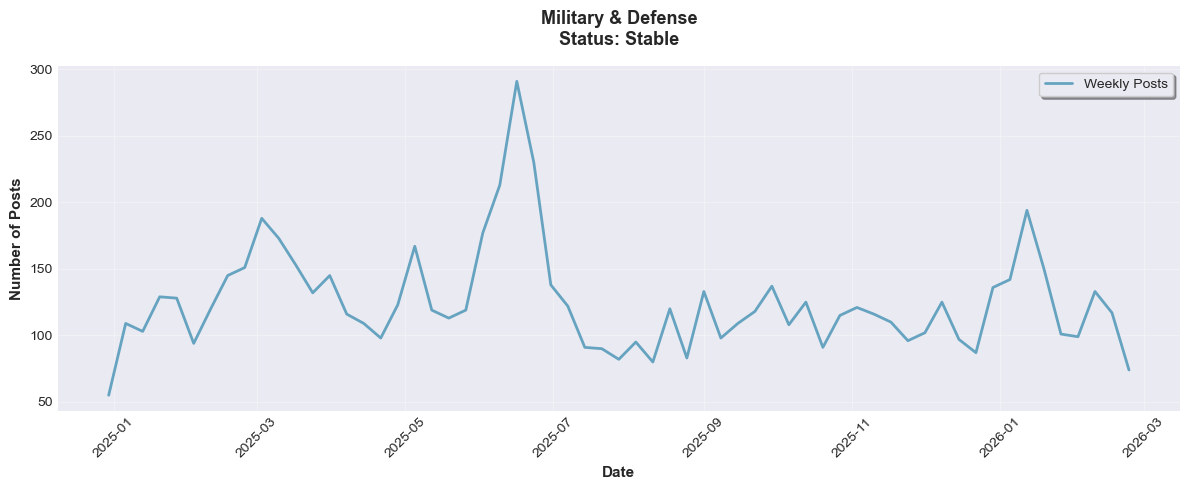

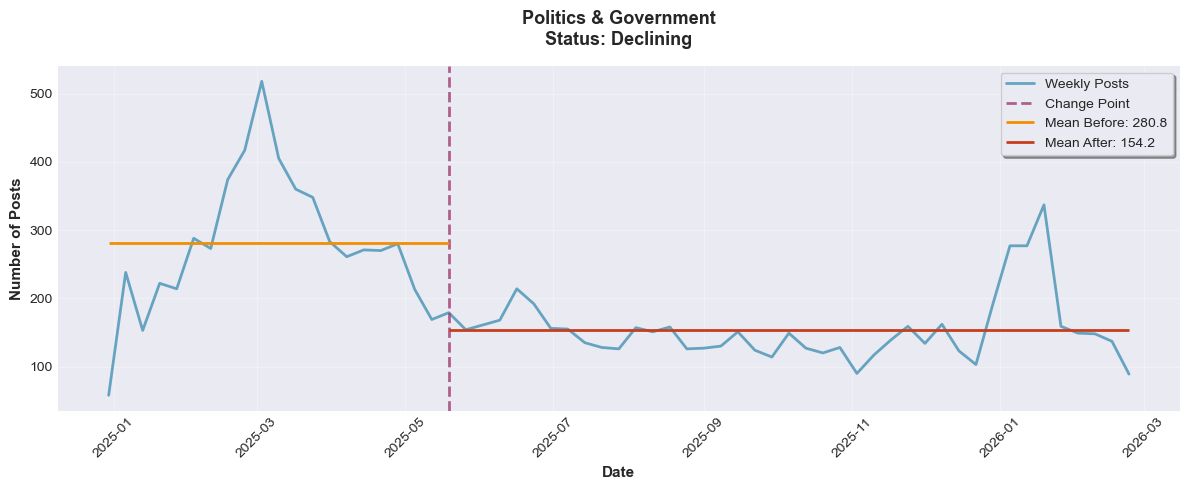

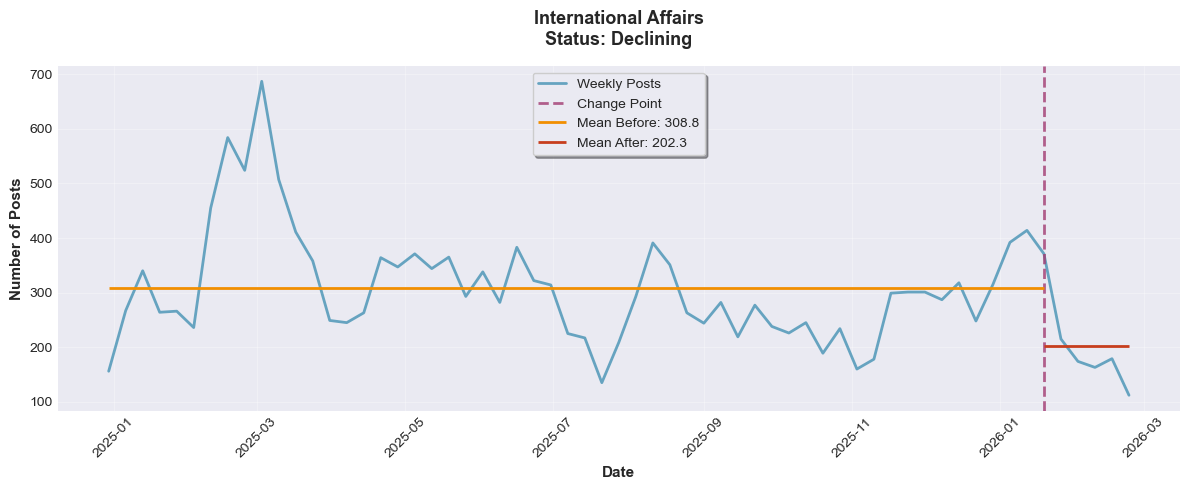

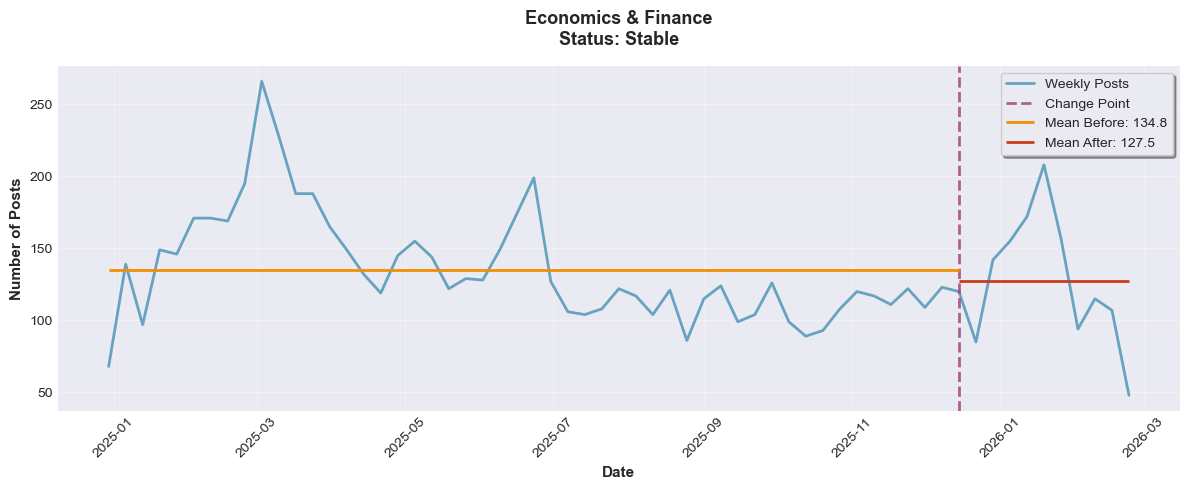

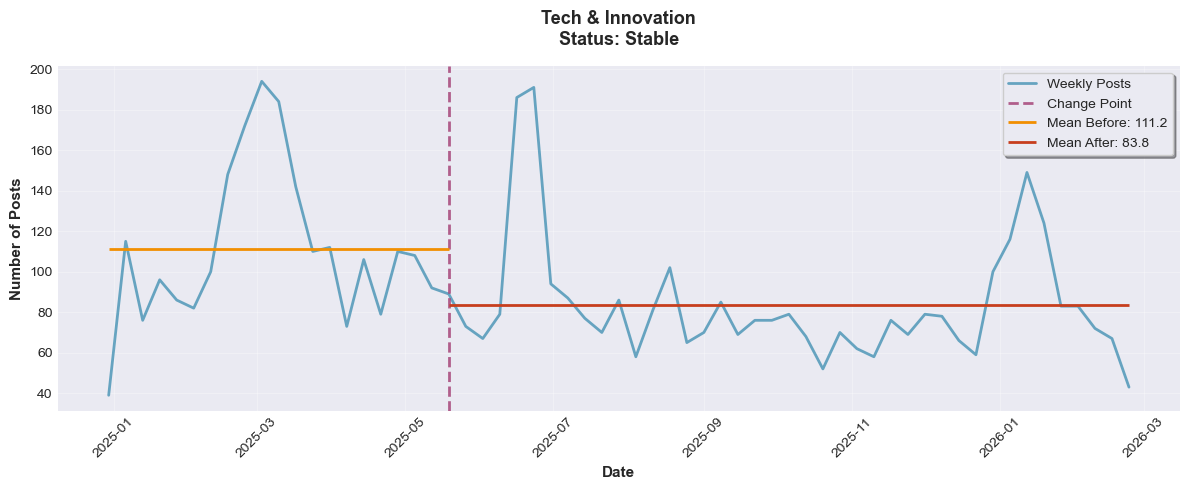

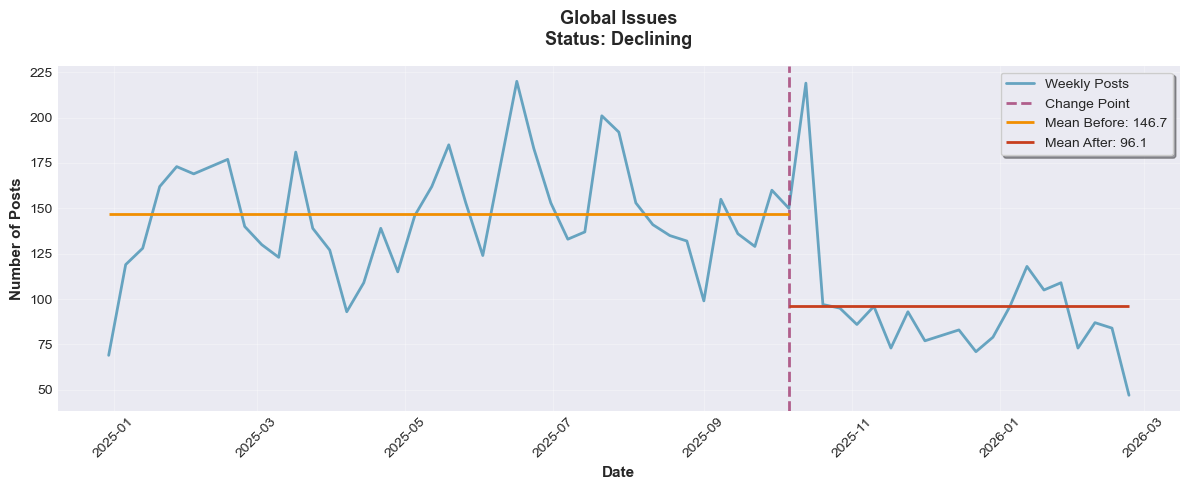

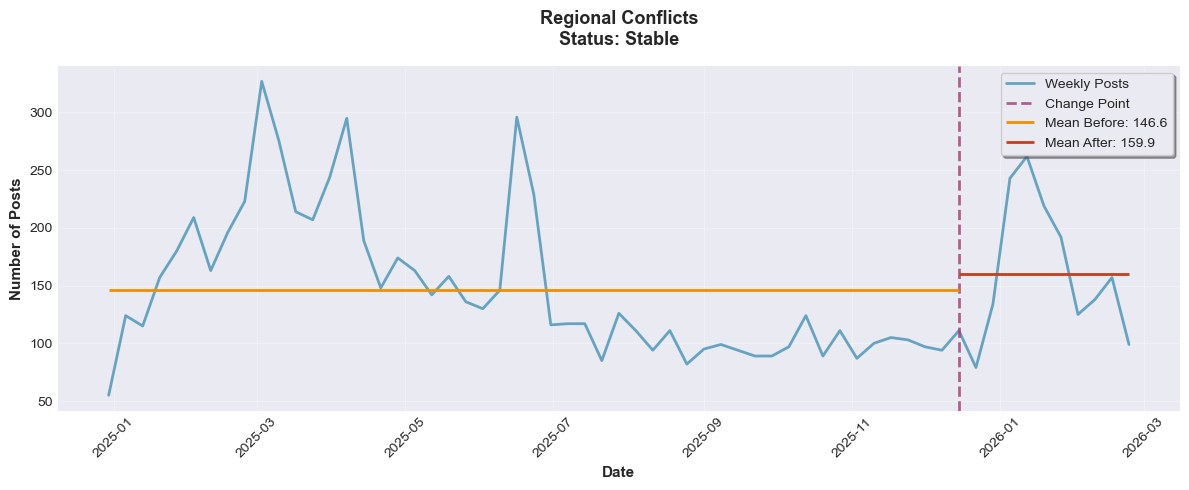

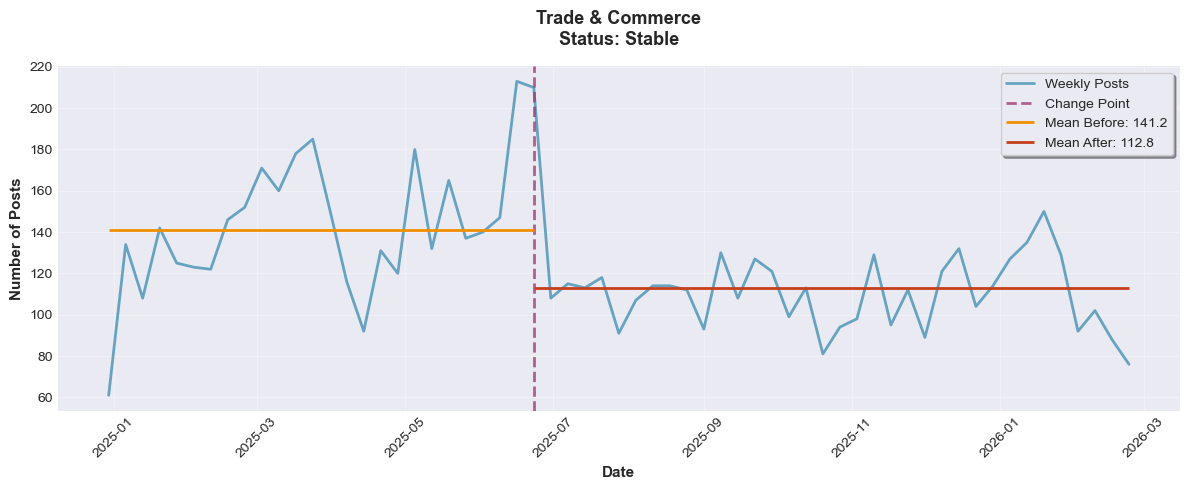

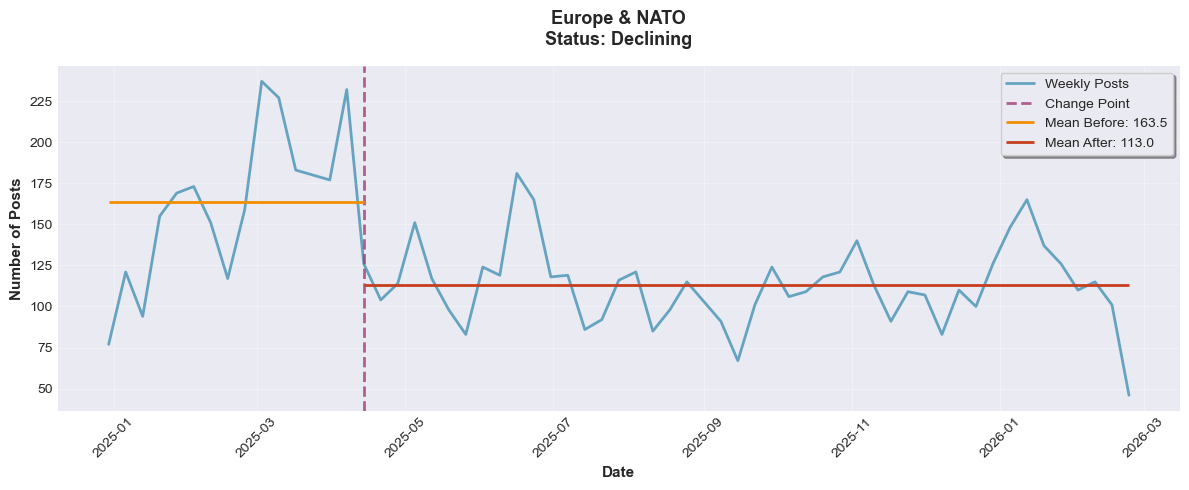

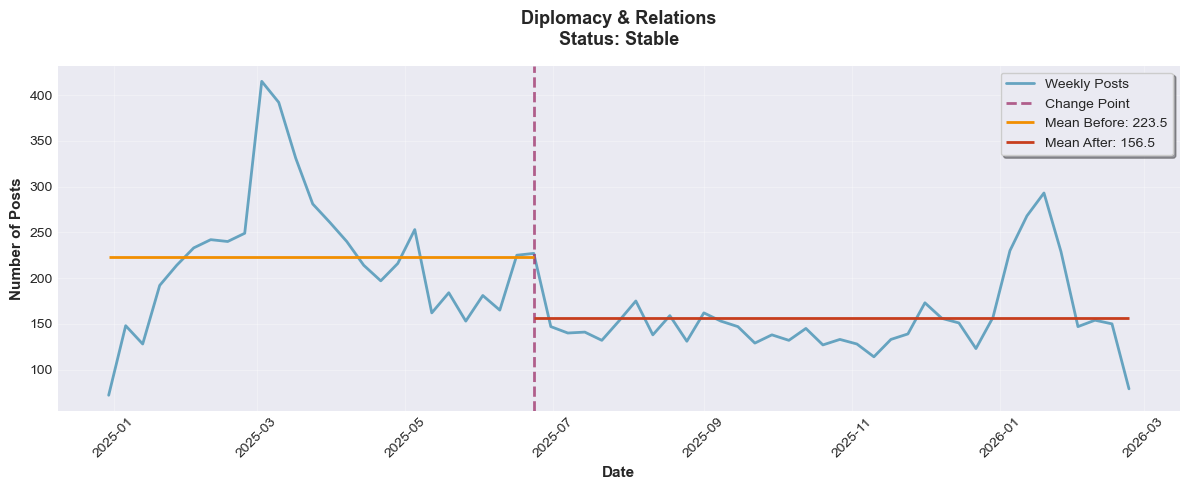


✓ Generated 10 plots in 'change_point_plots/' directory


In [32]:
import os

# Create output directory
os.makedirs('change_point_plots', exist_ok=True)

print("Generating visualizations...\n")

# Generate plot for each topic
for idx, row in results_df.iterrows():
    topic_col = row['Topic_ID']
    signal = time_series_df[topic_col].values
    
    # Detect change points again for plotting
    change_points = detect_change_points(signal, method='pelt', penalty=1.5)
    
    # Create plot
    save_path = f"change_point_plots/{topic_col}.png"
    plot_change_point_analysis(
        topic_col=topic_col,
        signal=signal,
        dates=time_series_df.index,
        change_points=change_points,
        mean_before=row['Mean_Before'],
        mean_after=row['Mean_After'],
        status=row['Status'],
        label=row['Label'],
        save_path=save_path
    )

print(f"\n✓ Generated {len(results_df)} plots in 'change_point_plots/' directory")

## 8. Save Results

Export final results to CSV file as required by Task C-6.

In [39]:
# Initialize results storage
all_results = []

# Get topic columns
topic_columns = [col for col in time_series_df.columns if col.startswith('topic_')]

print(f"Analyzing {len(topic_columns)} topics for CSV export...\n")

# Process each topic
for topic_col in topic_columns:
    # Extract time series
    signal = time_series_df[topic_col].values
    
    # Detect change points using PELT algorithm
    change_points = detect_change_points(signal, method='pelt', penalty=1.5)
    
    # Validate trend
    status, growth, change_date, mean_before, mean_after = validate_trend(
        signal, change_points, time_series_df.index
    )
    
    # Get topic label
    topic_id = topic_col.replace('topic_', '')
    topic_label = labels_dict.get(topic_id, f"Topic {topic_id}")
    
    # Store results
    all_results.append({
        'Topic_ID': topic_col,
        'Label': topic_label,
        'Change_Date': change_date,
        'Growth_Rate': growth,
        'Mean_Before': mean_before,
        'Mean_After': mean_after,
        'Status': status,
        'Change_Points': len(change_points)
    })
    
    print(f"{topic_col}: {status} (Growth: {growth}x)")

# Create DataFrame from all results
results_df = pd.DataFrame(all_results)

# Save results to CSV
output_file = 'emerging_trends_results.csv'
results_df.to_csv(output_file, index=False)

print(f"\n✓ Results saved to: {output_file}")
print(f"✓ Visualizations saved to: change_point_plots/")
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"\nTotal Topics Analyzed: {len(results_df)}")
print(f"Emerging Trends: {len(results_df[results_df['Status'] == 'Emerging'])}")
print(f"Stable Trends: {len(results_df[results_df['Status'] == 'Stable'])}")
print(f"Declining Trends: {len(results_df[results_df['Status'] == 'Declining'])}")

Analyzing 10 topics for CSV export...

topic_0: Stable (Growth: 1.0x)
topic_1: Declining (Growth: 0.55x)
topic_2: Declining (Growth: 0.66x)
topic_3: Stable (Growth: 0.95x)
topic_4: Stable (Growth: 0.75x)
topic_5: Declining (Growth: 0.66x)
topic_6: Stable (Growth: 1.09x)
topic_7: Stable (Growth: 0.8x)
topic_8: Declining (Growth: 0.69x)
topic_9: Stable (Growth: 0.7x)

✓ Results saved to: emerging_trends_results.csv
✓ Visualizations saved to: change_point_plots/

ANALYSIS COMPLETE

Total Topics Analyzed: 10
Emerging Trends: 0
Stable Trends: 6
Declining Trends: 4


---

## Summary

This notebook successfully implements:

### 01: Change Point Detection
- Applied PELT algorithm from ruptures library
- Detected significant shifts in topic popularity over time
- Used RBF (Radial Basis Function) model for robust detection

### 02: Statistical Validation
- Calculated growth rates (mean before vs mean after change points)
- Classified trends as Emerging (growth > 2x), Stable, or Declining
- Verified recency of change points (within last 12 weeks)

### 03: Results & Visualizations
- Generated `emerging_trends_results.csv` with complete analysis
- Created change point plots with before/after mean lines
- Saved all visualizations as PNG files

### Deliverables
1. ✅ `emerging_trends_results.csv` - Complete results table
2. ✅ `change_point_plots/` - Directory with 10 PNG plots
3. ✅ `3_change_point_detection.ipynb` - This notebook

---

**Next Steps for Week 3:**
- Integrate results into Streamlit dashboard
- Add interactive trend exploration features
- Combine with LDA model for complete system